# Fractured X-ray Image Augmentation

This notebook performs data augmentation on fractured X-ray images to address class imbalance.

## Problem
- Fractured images: 717
- Non-fractured images: 3366
- Ratio: ~1:4.7 (highly imbalanced)

## Solution
Apply realistic X-ray image augmentations to fractured images only to increase their count.

## Approach
1. Use only images from the training set (based on Distribution/train.csv)
2. Apply albumentations with realistic X-ray transforms
3. Save augmented images to `datasets/images/Fractured_Aug/`
4. Maintain original image quality and realistic appearance


In [2]:
# Set up paths
import os
from pathlib import Path

# Base paths
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "datasets"
IMAGES_DIR = DATA_DIR / "images"
FRACTURED_DIR = IMAGES_DIR / "Fractured"
NON_FRACTURED_DIR = IMAGES_DIR / "Non_fractured"
FRACTURED_AUG_DIR = IMAGES_DIR / "Fractured_Aug"
DISTRIBUTION_DIR = BASE_DIR / "Distribution"

# Create augmented folder if it doesn't exist
FRACTURED_AUG_DIR.mkdir(exist_ok=True)

# Print directory structure
print("Directory structure:")
print(f"Base directory: {BASE_DIR}")
print(f"Images directory: {IMAGES_DIR}")
print(f"Fractured images: {FRACTURED_DIR}")
print(f"Non-fractured images: {NON_FRACTURED_DIR}")
print(f"Augmented fracture images will be saved to: {FRACTURED_AUG_DIR}")

# Count current images
fractured_count = len(list(FRACTURED_DIR.glob("*.jpg"))) + len(list(FRACTURED_DIR.glob("*.jpeg"))) + len(list(FRACTURED_DIR.glob("*.png")))
non_fractured_count = len(list(NON_FRACTURED_DIR.glob("*.jpg"))) + len(list(NON_FRACTURED_DIR.glob("*.jpeg"))) + len(list(NON_FRACTURED_DIR.glob("*.png")))

print(f"\nCurrent counts:")
print(f"Fractured images: {fractured_count}")
print(f"Non-fractured images: {non_fractured_count}")
print(f"Ratio (non-fractured : fractured): {non_fractured_count/fractured_count:.2f}:1")

Directory structure:
Base directory: /Users/gideonchua/Documents/STINTSY_MCO1/STINTSYMCO1/notebook
Images directory: /Users/gideonchua/Documents/STINTSY_MCO1/STINTSYMCO1/notebook/datasets/images
Fractured images: /Users/gideonchua/Documents/STINTSY_MCO1/STINTSYMCO1/notebook/datasets/images/Fractured
Non-fractured images: /Users/gideonchua/Documents/STINTSY_MCO1/STINTSYMCO1/notebook/datasets/images/Non_fractured
Augmented fracture images will be saved to: /Users/gideonchua/Documents/STINTSY_MCO1/STINTSYMCO1/notebook/datasets/images/Fractured_Aug

Current counts:
Fractured images: 717
Non-fractured images: 3366
Ratio (non-fractured : fractured): 4.69:1


In [72]:
# Load training split
train_csv_path = DISTRIBUTION_DIR / "train.csv"
print(f"Loading training split from: {train_csv_path}")

try:
    train_df = pd.read_csv(train_csv_path)
    print(f"Training split loaded: {len(train_df)} images")
    print("\nFirst few rows:")
    print(train_df.head())
except Exception as e:
    print(f"Error loading CSV: {e}")
    # If CSV fails, we'll use all fractured images
    train_df = None

Loading training split from: /Users/gideonchua/Documents/STINTSY_MCO1/STINTSYMCO1/notebook/Distribution/train.csv
Training split loaded: 574 images

First few rows:
         image_id
0  IMG0000019.jpg
1  IMG0000025.jpg
2  IMG0000044.jpg
3  IMG0000057.jpg
4  IMG0000058.jpg


## Realistic X-ray Image Augmentations

For medical X-ray images, we need transformations that are physically plausible:

1. **Geometric transforms**: Small rotations, flips (horizontal only for symmetry)
2. **Intensity transforms**: Brightness/contrast adjustments (mimicking exposure variations)
3. **Noise**: Gaussian noise (simulates sensor noise)
4. **Blur**: Mild Gaussian blur (simulates slight motion or focus issues)
5. **Elastic transforms**: Simulate tissue deformation

**Important**: We avoid:
- Severe color shifts (X-rays are grayscale)
- Large rotations (>15 degrees) - unrealistic for positioned X-rays
- Vertical flips - bones don't appear upside down
- Extreme distortions

In [73]:
# Define realistic X-ray augmentations using albumentations
import albumentations as A

# Realistic X-ray augmentations pipeline
# These transforms mimic actual X-ray variations
xray_augmentation = A.Compose([
    # Geometric transforms (small, realistic)
    A.HorizontalFlip(p=0.3),  # Left-right flip is realistic for symmetrical body parts
    A.Rotate(limit=15, p=0.4),  # Small rotations (patient slightly tilted)
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=10, p=0.3),
    
    # Intensity/brightness variations (different exposure levels)
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),
    
    # Noise and blur (sensor noise, slight motion blur)
    A.GaussNoise(var_limit=(0.02), p=0.3),  # Mild Gaussian noise
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),  # Slight blur
    
    # Elastic transform (simulate tissue deformation)
    A.ElasticTransform(alpha=1, sigma=25, alpha_affine=25, p=0.1),
    
    # X-ray specific: adjust gamma (exposure correction)
    A.RandomGamma(gamma_limit=(90, 110), p=0.3),
    
    # Ensure we don't break the image
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.2),
])

# Also create a simpler augmentation for variety
simple_augmentation = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.05, contrast_limit=0.05, p=0.5),
    A.GaussNoise(var_limit=(5.0, 10.0), p=0.3),
])

print("X-ray augmentation pipeline defined.")
print("\nAugmentation strategies:")
print("1. Full pipeline: Multiple realistic transforms")
print("2. Simple pipeline: Basic flips and noise")
print("\nNote: All transforms are physically plausible for X-ray images.")

X-ray augmentation pipeline defined.

Augmentation strategies:
1. Full pipeline: Multiple realistic transforms
2. Simple pipeline: Basic flips and noise

Note: All transforms are physically plausible for X-ray images.


/Users/gideonchua/Documents/STINTSY_MCO1/STINTSYMCO1/.venv/lib/python3.13/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/var/folders/r7/9l6d7kkj6ln9_5dqf9wn76h00000gn/T/ipykernel_1808/3104368473.py:16: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(0.02), p=0.3),  # Mild Gaussian noise
/var/folders/r7/9l6d7kkj6ln9_5dqf9wn76h00000gn/T/ipykernel_1808/3104368473.py:20: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=1, sigma=25, alpha_affine=25, p=0.1),
/var/folders/r7/9l6d7kkj6ln9_5dqf9wn76h00000gn/T/ipykernel_1808/3104368473.py:33: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 10.0), p=0.3),


In [74]:
# Function to load and augment images
def augment_fractured_images(augmentation_pipeline, num_augmentations_per_image=3):
    """
    Augment fractured images from the training set.
    
    Args:
        augmentation_pipeline: Albumentations pipeline
        num_augmentations_per_image: Number of augmented versions to create per image
    """
    
    # Get list of fractured images in training set
    if train_df is not None:
        # Filter only fractured images from training set
        training_images = set(train_df['image_id'].tolist())
        fractured_images = []
        
        for img_path in FRACTURED_DIR.glob("*.jpg"):
            if img_path.name in training_images:
                fractured_images.append(img_path)
        
        print(f"Found {len(fractured_images)} fractured images in training set")
    else:
        # Use all fractured images
        fractured_images = list(FRACTURED_DIR.glob("*.jpg"))
        print(f"Using all {len(fractured_images)} fractured images")
    
    if not fractured_images:
        print("No fractured images found!")
        return 0
    
    augmented_count = 0
    
    # Process each image
    for i, img_path in enumerate(fractured_images):
        try:
            # Load image
            image = cv2.imread(str(img_path))
            if image is None:
                print(f"Warning: Could not load {img_path.name}")
                continue
            
            # Convert BGR to RGB for processing
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
            # Create augmented versions
            for aug_idx in range(num_augmentations_per_image):
                # Apply augmentation
                augmented = augmentation_pipeline(image=image)
                aug_image = augmented['image']
                
                # Generate new filename
                original_stem = img_path.stem
                aug_filename = f"{original_stem}_aug{aug_idx+1:03d}.jpg"
                aug_path = FRACTURED_AUG_DIR / aug_filename
                
                # Convert back to BGR for saving
                aug_image_bgr = cv2.cvtColor(aug_image, cv2.COLOR_RGB2BGR)
                
                # Save augmented image
                cv2.imwrite(str(aug_path), aug_image_bgr, [cv2.IMWRITE_JPEG_QUALITY, 95])
                
                augmented_count += 1
                
                # Show progress
                if augmented_count % 50 == 0:
                    print(f"  Created {augmented_count} augmented images...")
            
            # Show progress per original image
            if (i + 1) % 50 == 0:
                print(f"Processed {i + 1}/{len(fractured_images)} original images")
                
        except Exception as e:
            print(f"Error processing {img_path.name}: {e}")
    
    return augmented_count

In [1]:
# Let's test the augmentation on a few images first
print("Testing augmentation on sample images...")

# Find a few sample images
sample_images = list(FRACTURED_DIR.glob("*.jpg"))[:3]

if sample_images:
    fig, axes = plt.subplots(3, 2, figsize=(10, 12))
    
    for i, img_path in enumerate(sample_images):
        # Load original
        original = cv2.imread(str(img_path))
        original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
        
        # Apply augmentation
        augmented = xray_augmentation(image=original)
        aug_image = augmented['image']
        
        # Plot
        axes[i, 0].imshow(original, cmap='gray' if len(original.shape) == 2 else None)
        axes[i, 0].set_title(f"Original: {img_path.name}")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(aug_image, cmap='gray' if len(aug_image.shape) == 2 else None)
        axes[i, 1].set_title(f"Augmented")
        axes[i, 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    print("Sample augmentation test complete.")
else:
    print("No sample images found for testing.")

Testing augmentation on sample images...


NameError: name 'FRACTURED_DIR' is not defined

In [67]:
# Now augment all fractured training images
print("Starting augmentation of fractured training images...")
print("Augmented images will be saved to: {FRACTURED_AUG_DIR}")

# Use the full augmentation pipeline
augmented_count = augment_fractured_images(
    augmentation_pipeline=xray_augmentation,
    num_augmentations_per_image=3  # Create 3 augmented versions per image
)

print(f"\nAugmentation complete!")
print(f"Created {augmented_count} new augmented images")

# Count augmented images
actual_augmented = len(list(FRACTURED_AUG_DIR.glob("*.jpg")))
print(f"Actual files in augmented folder: {actual_augmented}")

Starting augmentation of fractured training images...
Augmented images will be saved to: {FRACTURED_AUG_DIR}
Found 574 fractured images in training set
  Created 50 augmented images...
  Created 100 augmented images...
  Created 150 augmented images...
Processed 50/574 original images
  Created 200 augmented images...
  Created 250 augmented images...
  Created 300 augmented images...
Processed 100/574 original images
  Created 350 augmented images...
  Created 400 augmented images...
  Created 450 augmented images...
Processed 150/574 original images
  Created 500 augmented images...
  Created 550 augmented images...
  Created 600 augmented images...
Processed 200/574 original images
  Created 650 augmented images...
  Created 700 augmented images...
  Created 750 augmented images...
Processed 250/574 original images
  Created 800 augmented images...
  Created 850 augmented images...
  Created 900 augmented images...
Processed 300/574 original images
  Created 950 augmented images...


In [68]:
# Calculate new class balance
print("\n--- Class Balance Analysis ---")

# Count all fractured images (original + augmented)
all_fractured = fractured_count + actual_augmented

print(f"Original fractured images: {fractured_count}")
print(f"Augmented fractured images: {actual_augmented}")
print(f"Total fractured images: {all_fractured}")
print(f"Non-fractured images: {non_fractured_count}")
print(f"\nNew ratio (non-fractured : fractured): {non_fractured_count/all_fractured:.2f}:1")
print(f"Old ratio: {non_fractured_count/fractured_count:.2f}:1")
print(f"Improvement: {((non_fractured_count/fractured_count) / (non_fractured_count/all_fractured)):.1f}x more balanced")


--- Class Balance Analysis ---
Original fractured images: 717
Augmented fractured images: 1722
Total fractured images: 2439
Non-fractured images: 3366

New ratio (non-fractured : fractured): 1.38:1
Old ratio: 4.69:1
Improvement: 3.4x more balanced



--- Class Distribution Visualization ---


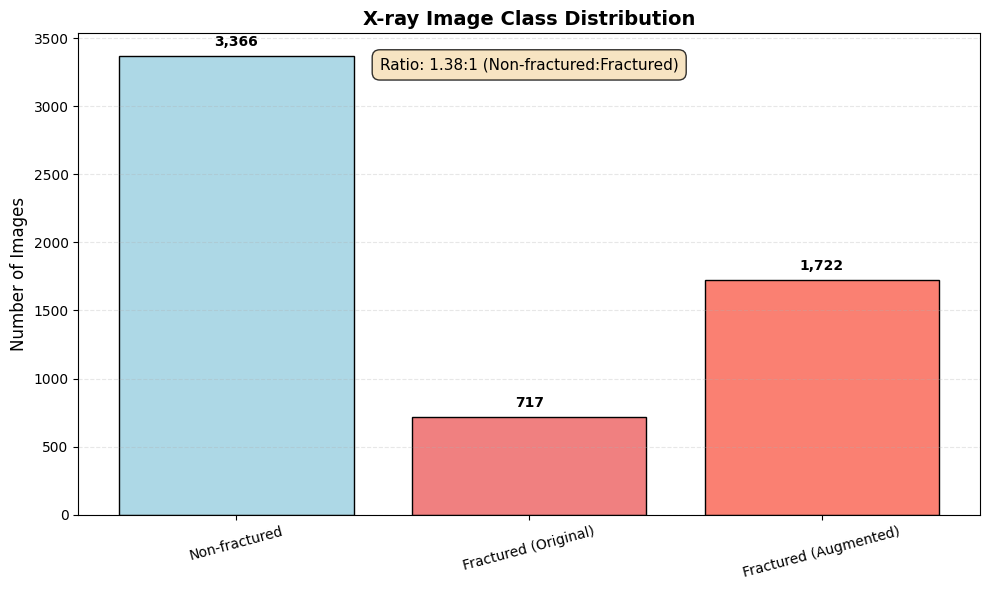

In [69]:
# Optional: Create a simple visualization of the class distribution
print("\n--- Class Distribution Visualization ---")

categories = ['Non-fractured', 'Fractured (Original)', 'Fractured (Augmented)']
counts = [non_fractured_count, fractured_count, actual_augmented]
colors = ['lightblue', 'lightcoral', 'salmon']

plt.figure(figsize=(10, 6))
bars = plt.bar(categories, counts, color=colors, edgecolor='black')

# Add count labels on bars
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{count:,}', ha='center', va='bottom', fontweight='bold')

plt.title('X-ray Image Class Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add ratio annotation
ratio_text = f'Ratio: {non_fractured_count/all_fractured:.2f}:1 (Non-fractured:Fractured)'
plt.text(0.5, 0.95, ratio_text, transform=plt.gca().transAxes,
         ha='center', va='top', fontsize=11,
         bbox=dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

In [70]:
# Final step: Create a summary file
summary_path = FRACTURED_AUG_DIR / "augmentation_summary.txt"
summary_content = f"""# Fractured Image Augmentation Summary

## Timestamp: {pd.Timestamp.now()}

## Original Counts:
- Fractured images: {fractured_count}
- Non-fractured images: {non_fractured_count}
- Original ratio: {non_fractured_count/fractured_count:.2f}:1 (non-fractured:fractured)

## Augmentation Results:
- Augmented images created: {actual_augmented}
- Total fractured images (original + augmented): {all_fractured}
- New ratio: {non_fractured_count/all_fractured:.2f}:1 (non-fractured:fractured)

## Augmentation Pipeline:
- Horizontal flips (30% probability)
- Small rotations (±15 degrees, 40% probability)
- Shift/scale/rotate combinations (30% probability)
- Brightness/contrast adjustments (50% probability)
- Gaussian noise (30% probability)
- Gaussian blur (20% probability)
- Elastic transforms (10% probability)
- Gamma adjustment (30% probability)
- CLAHE enhancement (20% probability)

## Notes:
- All transforms are physically plausible for X-ray images
- Only images from the training split were augmented
- Augmented images are saved with '_augXXX' suffix
"""

with open(summary_path, 'w') as f:
    f.write(summary_content)

print(f"\nSummary saved to: {summary_path}")


Summary saved to: /Users/gideonchua/Documents/STINTSY_MCO1/STINTSYMCO1/notebook/datasets/images/Fractured_Aug/augmentation_summary.txt


## Next Steps

1. **Update training** to include augmented images:
   - Combine `Fractured/` and `Fractured_Aug/` images during training
   - Update your data loading code to include both folders

2. **Training recommendation**:
   - Use class weights or oversampling to further balance the dataset
   - Monitor validation metrics closely to ensure augmentation helps

3. **Quality check**:
   - Manually review some augmented images to ensure they look realistic
   - Adjust augmentation parameters if images look artificial

4. **Optional**: Create a validation set from augmented images for proper evaluation

In [ ]:
# Cleanup: remove temporary test file
import os
if os.path.exists('check_albumentations.py'):
    os.remove('check_albumentations.py')
    print("Temporary file cleaned up.")